In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Data/Prestamos_Data_Alumnos_v5.xlsx")

df.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,O77MPJ,26,19153.0,6973,706,9.0,1,19.05,36.0,0.10,Grado Universitario,Jornada completa,Soltero,0.0,1.0,Automóvil,1.0,1,130.83
1,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,Soltero,1.0,1.0,Vivienda,0.0,0,65.85
2,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,Casado,1.0,1.0,Vivienda,0.0,0,260.60
3,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,221.02
4,KG9CT9,34,56572.0,73978,763,86.0,1,13.91,60.0,0.55,Máster,Tiempo parcial,Soltero,0.0,0.0,Educación,0.0,0,800.00


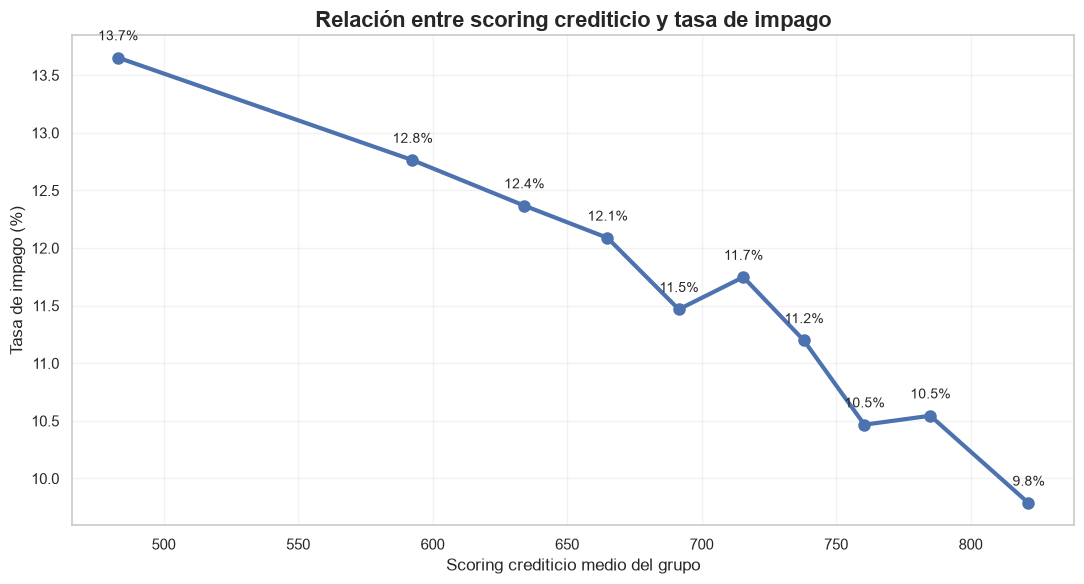

In [ ]:
# GRÁFICO 1: SCORING VS TASA DE IMPAGO

# Dividimos el scoring en 10 grupos con aproximadamente
# el mismo número de clientes en cada grupo
df["Grupo_Scoring"] = pd.qcut(
    df["Scoring_Crediticio"],
    q=10,
    duplicates="drop"
)

# Calculamos la tasa de impago de cada grupo
tasa_scoring = (
    df.groupby("Grupo_Scoring", observed=True)["Impago"]
      .mean() * 100
)

# Calculamos el punto medio de cada intervalo
puntos_scoring = [
    (intervalo.left + intervalo.right) / 2
    for intervalo in tasa_scoring.index
]

# Crear gráfico
plt.figure(figsize=(11, 6))

plt.plot(
    puntos_scoring,
    tasa_scoring.values,
    marker="o",
    linewidth=3,
    markersize=8
)

# Añadir los valores encima de los puntos
for x, y in zip(puntos_scoring, tasa_scoring.values):
    plt.text(
        x,
        y + 0.15,
        f"{y:.1f}%",
        ha="center",
        fontsize=10
    )

plt.title(
    "Relación entre scoring crediticio y tasa de impago",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Scoring crediticio medio del grupo", fontsize=12)
plt.ylabel("Tasa de impago (%)", fontsize=12)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# Se observa una relación negativa entre el scoring crediticio y la tasa de impago. Los clientes con puntuaciones crediticias más bajas presentan una mayor proporción de impagos, mientras que esta tasa disminuye progresivamente en los grupos con mayor scoring. Por tanto, el scoring parece ser una variable especialmente relevante para diferenciar perfiles de riesgo y podría tener una elevada utilidad en posteriores modelos predictivos.

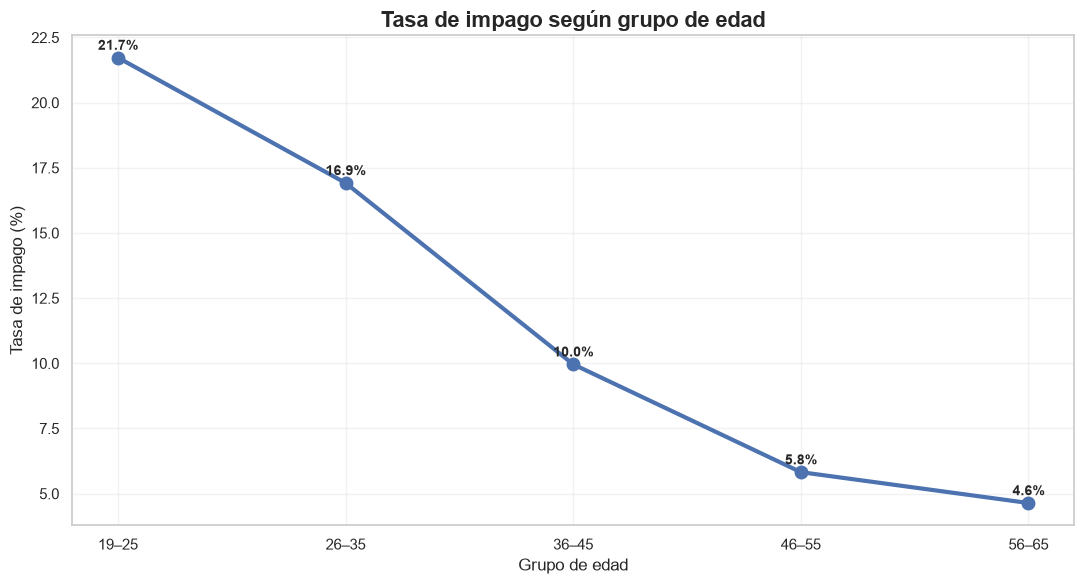

In [ ]:
# GRÁFICO 2: EDAD VS TASA DE IMPAGO

# Crear grupos de edad
df["Grupo_Edad"] = pd.cut(
    df["Edad"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=[
        "19–25",
        "26–35",
        "36–45",
        "46–55",
        "56–65",
        "66+"
    ]
)

# Calcular tasa de impago
tasa_edad = (
    df.groupby("Grupo_Edad", observed=True)["Impago"]
      .mean() * 100
)

# Crear gráfico
plt.figure(figsize=(11, 6))

plt.plot(
    tasa_edad.index.astype(str),
    tasa_edad.values,
    marker="o",
    linewidth=3,
    markersize=9
)

# Añadir porcentajes
for i, valor in enumerate(tasa_edad.values):
    plt.text(
        i,
        valor + 0.3,
        f"{valor:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Tasa de impago según grupo de edad",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Grupo de edad", fontsize=12)
plt.ylabel("Tasa de impago (%)", fontsize=12)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
#La tasa de impago presenta diferencias importantes entre los grupos de edad. El grupo más joven concentra una tasa de impago notablemente superior, mientras que esta disminuye en los grupos de mayor edad. Esto sugiere que la edad puede ser una variable relevante a la hora de identificar perfiles de riesgo, aunque su efecto debería analizarse conjuntamente con otras características financieras.

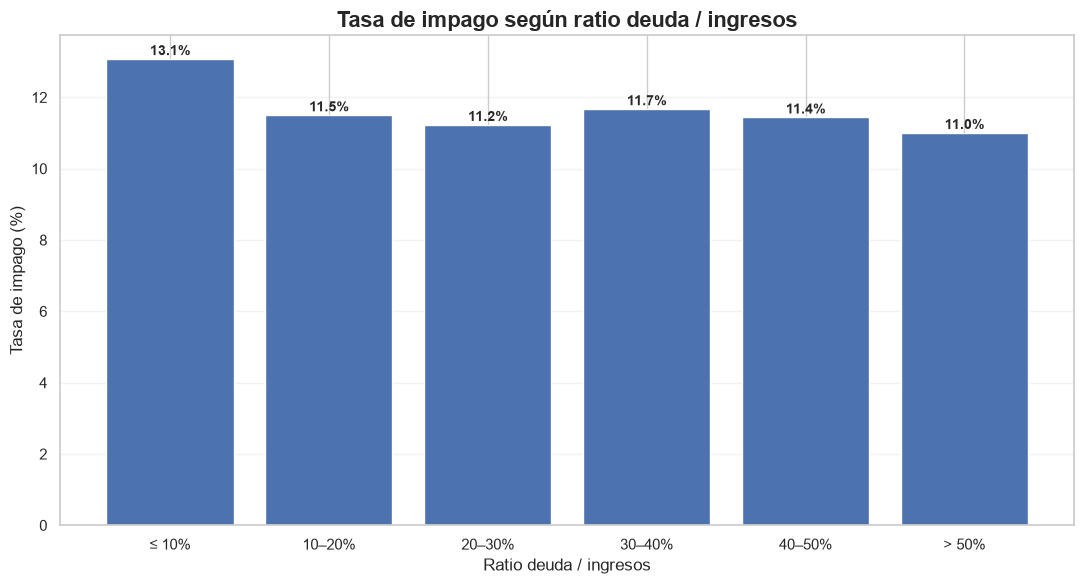

In [ ]:
# GRÁFICO 3: RATIO DEUDA/INGRESOS VS IMPAGO

# Crear intervalos del ratio deuda/ingresos
df["Grupo_DTI"] = pd.cut(
    df["Ratio_Deuda_Ingresos"],
    bins=[
        -np.inf,
        0.10,
        0.20,
        0.30,
        0.40,
        0.50,
        np.inf
    ],
    labels=[
        "≤ 10%",
        "10–20%",
        "20–30%",
        "30–40%",
        "40–50%",
        "> 50%"
    ]
)

# Calcular tasa de impago
tasa_dti = (
    df.groupby("Grupo_DTI", observed=True)["Impago"]
      .mean() * 100
)

# Crear gráfico
plt.figure(figsize=(11, 6))

barras = plt.bar(
    tasa_dti.index.astype(str),
    tasa_dti.values
)

# Mostrar porcentaje encima de cada barra
for barra, valor in zip(barras, tasa_dti.values):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        valor + 0.1,
        f"{valor:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Tasa de impago según ratio deuda / ingresos",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Ratio deuda / ingresos", fontsize=12)
plt.ylabel("Tasa de impago (%)", fontsize=12)

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
#A diferencia de lo que podría esperarse inicialmente, no se observa una relación claramente creciente entre el ratio deuda/ingresos y la tasa de impago. Las diferencias entre los grupos son relativamente reducidas. Esto indica que esta variable, analizada de forma aislada, podría tener una capacidad discriminante limitada y que probablemente resulte más útil combinada con otras variables financieras.

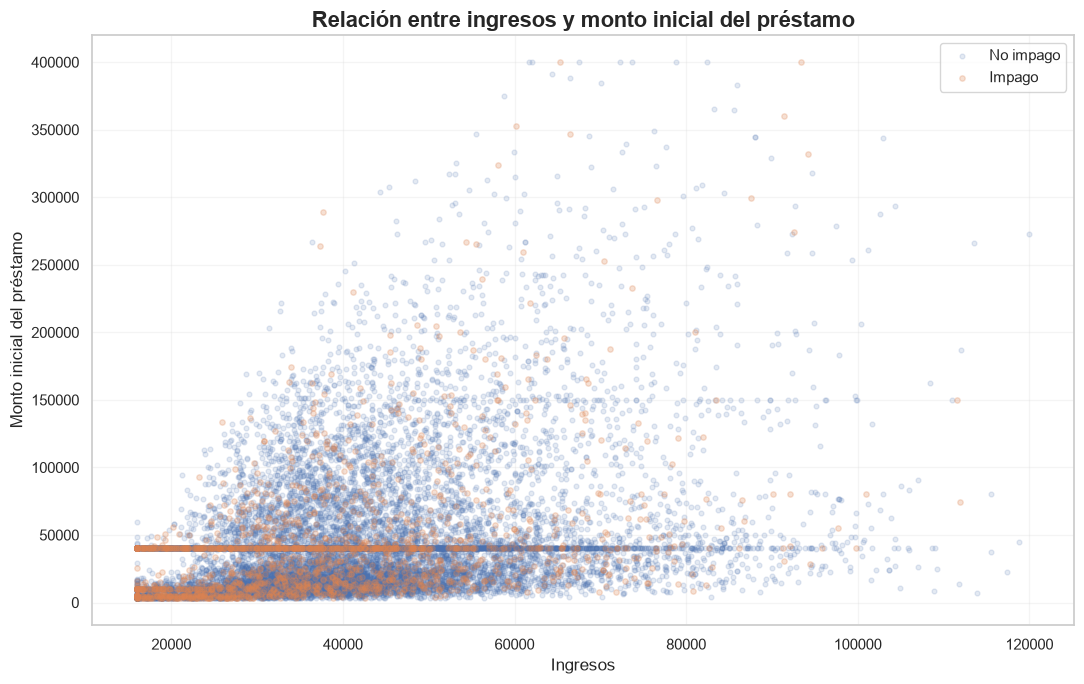

In [ ]:
# GRÁFICO 4: INGRESOS VS MONTO DEL PRÉSTAMO

# Seleccionamos una muestra para que el gráfico
# sea más fácil de interpretar visualmente
muestra = df[
    ["Ingresos", "Monto_Inicial", "Impago"]
].dropna().sample(
    n=15000,
    random_state=42
)

plt.figure(figsize=(11, 7))

# Dibujamos los préstamos sin impago
plt.scatter(
    muestra.loc[muestra["Impago"] == 0, "Ingresos"],
    muestra.loc[muestra["Impago"] == 0, "Monto_Inicial"],
    alpha=0.15,
    s=12,
    label="No impago"
)

# Dibujamos los préstamos con impago
plt.scatter(
    muestra.loc[muestra["Impago"] == 1, "Ingresos"],
    muestra.loc[muestra["Impago"] == 1, "Monto_Inicial"],
    alpha=0.25,
    s=15,
    label="Impago"
)

plt.title(
    "Relación entre ingresos y monto inicial del préstamo",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Ingresos", fontsize=12)
plt.ylabel("Monto inicial del préstamo", fontsize=12)

plt.legend()

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
#El gráfico muestra una elevada dispersión entre los ingresos y el importe inicial del préstamo. Aunque existe cierta concentración de préstamos de mayor importe en determinados niveles de ingresos, la relación no es perfectamente lineal. La representación también permite observar la distribución de los préstamos con y sin impago. Esta relación puede ser útil para construir posteriormente variables derivadas como el importe del préstamo respecto a los ingresos.

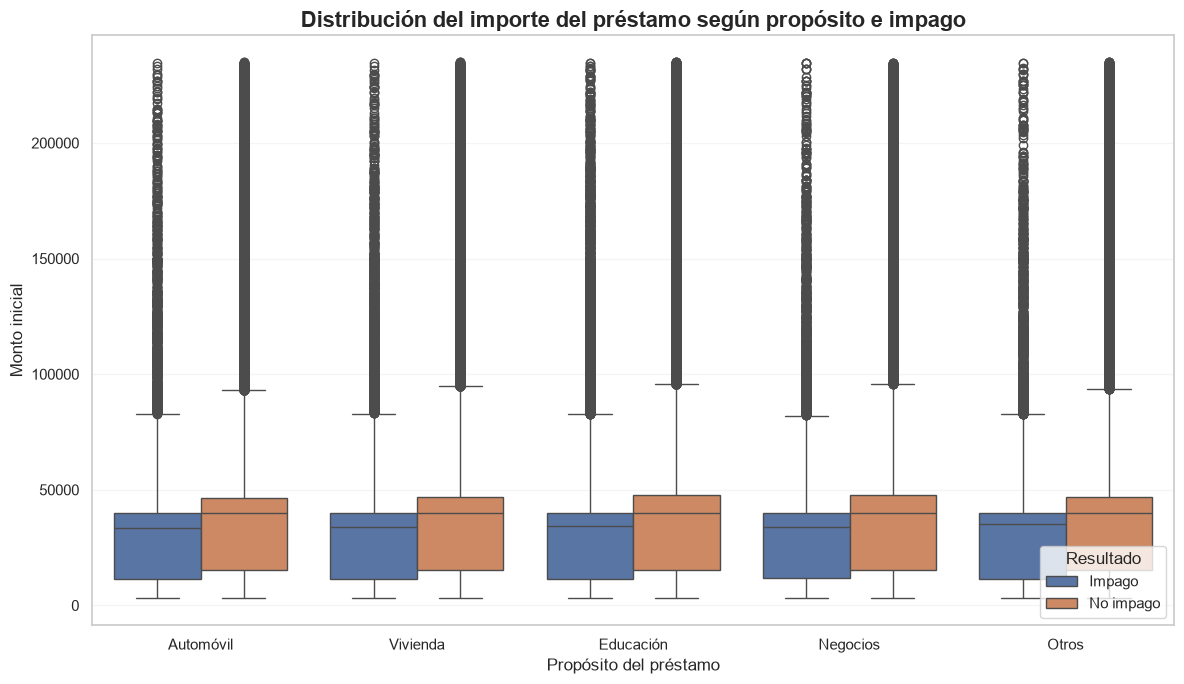

In [ ]:
# GRÁFICO 5: IMPORTE SEGÚN PROPÓSITO E IMPAGO

# Eliminamos valores extremos del 1% superior
# para poder visualizar mejor las cajas
limite = df["Monto_Inicial"].quantile(0.99)

df_boxplot = df[
    df["Monto_Inicial"] <= limite
].copy()

# Convertimos Impago en texto
df_boxplot["Estado"] = df_boxplot["Impago"].map({
    0: "No impago",
    1: "Impago"
})

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_boxplot,
    x="Proposito",
    y="Monto_Inicial",
    hue="Estado"
)

plt.title(
    "Distribución del importe del préstamo según propósito e impago",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Propósito del préstamo", fontsize=12)
plt.ylabel("Monto inicial", fontsize=12)

plt.legend(
    title="Resultado"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [ ]:
#Los boxplots permiten comparar simultáneamente el importe de los préstamos, su propósito y el resultado final. Se observa que las distribuciones presentan diferencias entre préstamos con y sin impago, aunque existe un importante solapamiento. Esto indica que el importe inicial no debería interpretarse como un indicador aislado de riesgo, sino en combinación con variables como ingresos, scoring y características personales.

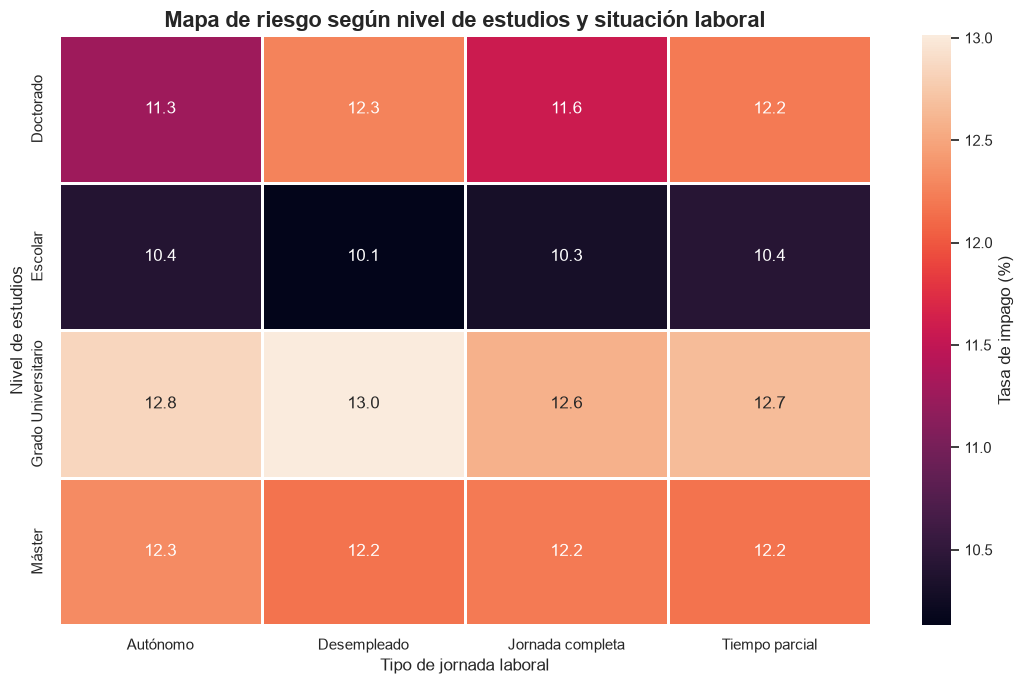

In [ ]:
# GRÁFICO 6: HEATMAP ESTUDIOS × JORNADA

# Crear tabla con la tasa media de impago
tabla_riesgo = pd.pivot_table(
    df,
    values="Impago",
    index="Estudios",
    columns="Tipo_Jornada_Laboral",
    aggfunc="mean"
) * 100

# Crear heatmap
plt.figure(figsize=(11, 7))

sns.heatmap(
    tabla_riesgo,
    annot=True,
    fmt=".1f",
    linewidths=1,
    cbar_kws={
        "label": "Tasa de impago (%)"
    }
)

plt.title(
    "Mapa de riesgo según nivel de estudios y situación laboral",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Tipo de jornada laboral",
    fontsize=12
)

plt.ylabel(
    "Nivel de estudios",
    fontsize=12
)

plt.tight_layout()
plt.show()

In [ ]:
#El mapa de calor permite analizar simultáneamente el nivel de estudios y la situación laboral. Se observan diferencias en la tasa de impago dependiendo de la combinación de ambas variables, lo que demuestra que determinadas características categóricas pueden adquirir mayor valor cuando se estudian conjuntamente. Este tipo de análisis resulta especialmente útil para detectar perfiles concretos de riesgo.

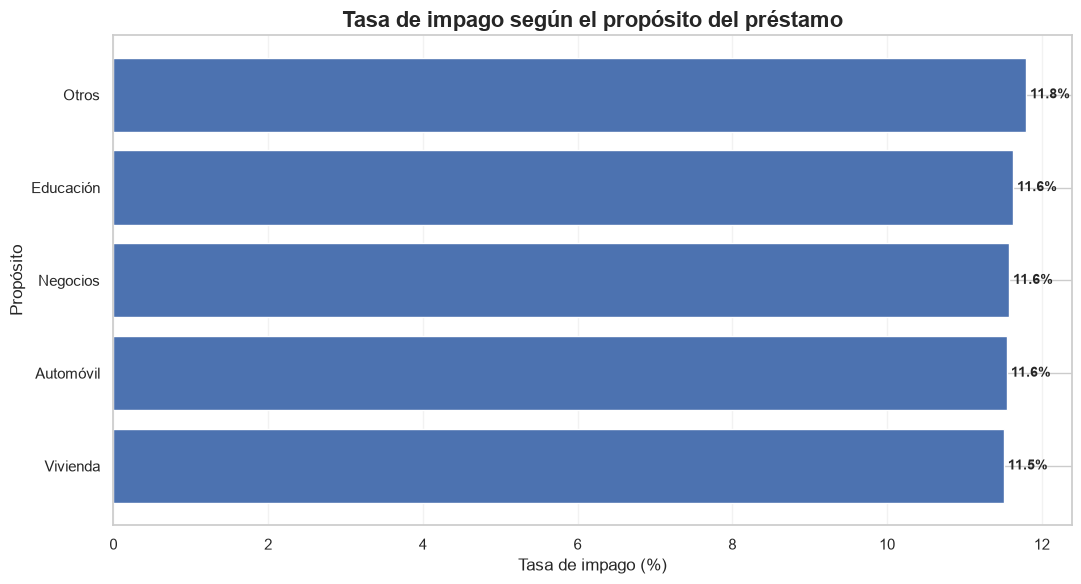

In [ ]:
# GRÁFICO 7: PROPÓSITO VS TASA DE IMPAGO

# Calcular tasa de impago por propósito
tasa_proposito = (
    df.groupby("Proposito")["Impago"]
      .mean()
      .mul(100)
      .sort_values()
)

plt.figure(figsize=(11, 6))

barras = plt.barh(
    tasa_proposito.index,
    tasa_proposito.values
)

# Añadir porcentaje
for barra, valor in zip(barras, tasa_proposito.values):
    plt.text(
        valor + 0.05,
        barra.get_y() + barra.get_height()/2,
        f"{valor:.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Tasa de impago según el propósito del préstamo",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Tasa de impago (%)",
    fontsize=12
)

plt.ylabel(
    "Propósito",
    fontsize=12
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [ ]:
#Las tasas de impago son bastante similares entre los diferentes propósitos del préstamo. Por tanto, el propósito parece presentar una capacidad discriminante menor que otras variables como el scoring o la edad. Este resultado es relevante para el análisis exploratorio, ya que permite identificar qué variables podrían tener mayor interés en las fases posteriores de selección de características y modelización.

### Conclusiones del análisis exploratorio inicial

El análisis gráfico permite identificar diferencias relevantes en la tasa de impago según determinadas características de los clientes y de los préstamos. Destacan especialmente el **scoring crediticio y la edad**, que muestran relaciones claras con el comportamiento de impago. En cambio, variables como el **propósito del préstamo o el ratio deuda/ingresos**, consideradas individualmente, presentan diferencias más reducidas.

Además, el análisis conjunto de variables categóricas mediante el mapa de calor muestra que determinadas combinaciones de características pueden generar perfiles de riesgo diferenciados. Por tanto, estos resultados justifican continuar el análisis incorporando relaciones multivariantes y modelos predictivos, en lugar de analizar cada variable de forma independiente.